<a href="https://colab.research.google.com/github/trupthirao1505/HousePricePrediction-Property-Recommendation/blob/main/HousePricePrediction%26Property_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = {
    'Area': [850, 900, 1000, 1100, 1200, 1300, 1400, 1500,
             1600, 1700, 1800, 1900, 2000, 2200, 2500],

    'Bedrooms': [2, 2, 2, 3, 3, 3, 3, 3,
                 4, 4, 4, 4, 4, 5, 5],

    'Bathrooms': [1, 1, 2, 2, 2, 2, 2, 3,
                  3, 3, 3, 3, 4, 4, 4],

    'Age': [15, 12, 10, 8, 7, 6, 5, 5,
            4, 4, 3, 3, 2, 2, 1],

    'Price': [35, 38, 45, 50, 55, 60, 65, 72,
              80, 87, 95, 102, 110, 125, 145]
}

df = pd.DataFrame(data)

df

,Area,Bedrooms,Bathrooms,Age,Price
0,850,2,1,15,35
1,900,2,1,12,38
2,1000,2,2,10,45
3,1100,3,2,8,50
4,1200,3,2,7,55
5,1300,3,2,6,60
6,1400,3,2,5,65
7,1500,3,3,5,72
8,1600,4,3,4,80
9,1700,4,3,4,87


In [ ]:
df.head()

,Area,Bedrooms,Bathrooms,Age,Price
0,850,2,1,15,35
1,900,2,1,12,38
2,1000,2,2,10,45
3,1100,3,2,8,50
4,1200,3,2,7,55


In [ ]:
df.isnull().sum()

,0
Area,0
Bedrooms,0
Bathrooms,0
Age,0
Price,0


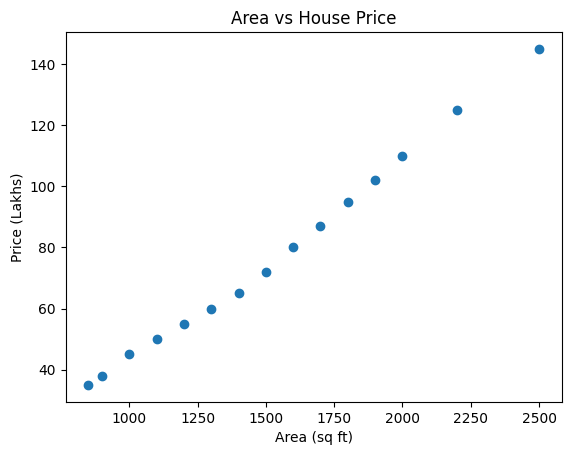

In [ ]:
plt.scatter(df['Area'], df['Price'])

plt.xlabel('Area (sq ft)')
plt.ylabel('Price (Lakhs)')
plt.title('Area vs House Price')

plt.show()

In [ ]:
X = df[['Area', 'Bedrooms', 'Bathrooms', 'Age']]

y = df['Price']

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   Area  Bedrooms  Bathrooms  Age
0   850         2          1   15
1   900         2          1   12
2  1000         2          2   10
3  1100         3          2    8
4  1200         3          2    7

Target:
0    35
1    38
2    45
3    50
4    55
Name: Price, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12, 4)
X_test shape: (3, 4)
y_train shape: (12,)
y_test shape: (3,)


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred)

Predicted Prices:
[ 88.80463051 101.4008528   41.17256933]


In [ ]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print(results)

   Actual Price  Predicted Price
0            87        88.804631
1           102       101.400853
2            35        41.172569


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-------------------")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Performance
-------------------
MAE : 2.8587823472060925
MSE : 13.905426943382736
RMSE: 3.7289981152291745
R² Score: 0.9831290317483897


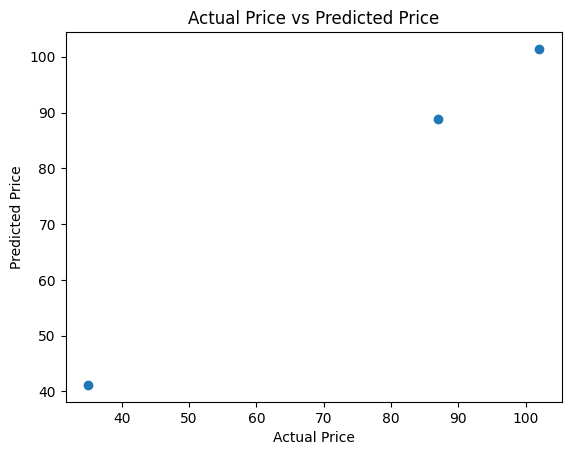

In [ ]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

plt.show()

In [ ]:
new_house = pd.DataFrame({
    'Area': [1800],
    'Bedrooms': [4],
    'Bathrooms': [3],
    'Age': [5]
})

prediction = model.predict(new_house)

print(f"Predicted House Price: ₹{prediction[0]:.2f} Lakhs")

Predicted House Price: ₹98.13 Lakhs


In [ ]:
print("HOUSE PRICE PREDICTION")
print("----------------------")

area = float(input("Enter house area (sq ft): "))
bedrooms = int(input("Enter number of bedrooms: "))
bathrooms = int(input("Enter number of bathrooms: "))
age = int(input("Enter house age (years): "))

new_house = pd.DataFrame({
    'Area': [area],
    'Bedrooms': [bedrooms],
    'Bathrooms': [bathrooms],
    'Age': [age]
})

predicted_price = model.predict(new_house)

print()
print("----------------------------")
print(f"Predicted Price: ₹{predicted_price[0]:.2f} Lakhs")
print("----------------------------")

HOUSE PRICE PREDICTION
----------------------
Enter house area (sq ft): 125
Enter number of bedrooms: 2
Enter number of bathrooms: 2
Enter house age (years): 100

----------------------------
Predicted Price: ₹161.97 Lakhs
----------------------------
